# Analysis of the phase vs withdrawal latency relationship

In [58]:
# Autoreloading of modules and files without restarting notebook.
%reload_ext autoreload
%autoreload 2

import os
import neo
import pyro
import tqdm
import torch
import pickle
import gpytorch
import numpy as np
import pandas as pd
from numpy import intp
from pathlib import Path
from quantities import s
from copy import deepcopy
import matplotlib.pyplot as plt
from scipy.fftpack import hilbert
from collections import defaultdict
from elephant.conversion import BinnedSpikeTrain

from rvm_analysis.colours import get_cell_colour
from rvm_analysis.save_tools import save_in_folder
from rvm_analysis.utils import import_spontaneous_cells
from rvm_analysis.colours import generate_color_spectrum
from rvm_analysis.simulations import generalized_poisson_sample
from rvm_analysis.non_poisson_gpytorch_model import PeriodicGPModel, PoissonUniformMixtureLikelihood


# Set random seed
torch.manual_seed(0)
pyro.set_rng_seed(0)
torch.set_default_dtype(torch.float64)

#! Force the backend back to matplotlib inline (after importing viziphant).
%matplotlib inline
print(plt.get_backend())

module://matplotlib_inline.backend_inline


## Importing the cut and uncut cell activity

In [ ]:
save_final_plots=False

In [59]:
base_save_dir = Path("../Gaussian_Processes/gpytorch_models/results/gen_pois_no_exp")
cell_activities_cut_to_spontaneous_pkl_path: Path = Path("../../CUT_CELL_ACTIVITIES_unzeroed.pkl")
cell_activities_uncut_pkl_path: Path = Path("../../UNCUT_CELL_ACTIVITIES.pkl")
saved_files_path: Path = Path("../../saved_files.pkl")

In [60]:
with open(cell_activities_cut_to_spontaneous_pkl_path, "rb") as file:
    cut_spikes_ON, cut_spikes_OFF, _, _ = pickle.load(file)

with open(cell_activities_uncut_pkl_path, "rb") as file:
    spikes_ON, spikes_OFF, _, _ = pickle.load(file)


cut_spikes_df = {
    "ON": cut_spikes_ON,
    "OFF": cut_spikes_OFF,
}
spikes_df = {
    "ON": spikes_ON,
    "OFF": spikes_OFF,
}

We will also need the full recordings to get trial latencies, so import the corresponding files that belong to each GP as well.

In [61]:
with open(saved_files_path, "rb") as f:
    files_spikes_ON, files_spikes_OFF, files_NEUTRAL, files_NEUTRAL_extra = pickle.load(f)

We further import all of the spontaneous cells as a Spike2DataManager, so these can be paired with the files.

In [62]:
dm = import_spontaneous_cells()

<sonpy.SonFile> object owning file ..\..\data\Spontaneous_Recordings_Melissa_Zhigang\Pared_Spike_Files\CA_ongoing01a_cut_pared.smrx
    DataType.AdcMark: 1, Spikes
    DataType.EventFall: 4, EKG
    DataType.EventRise: 6, heat
    DataType.EventRise: 7, flick
    DataType.Marker: 30, Keyboard
<sonpy.SonFile> object owning file ..\..\data\Spontaneous_Recordings_Melissa_Zhigang\Pared_Spike_Files\CA_ongoing01b_cut_pared.smrx
    DataType.AdcMark: 1, nw-1
    DataType.EventFall: 4, EKG
    DataType.EventRise: 6, heat
    DataType.EventRise: 7, flick
    DataType.Marker: 30, Keyboard
<sonpy.SonFile> object owning file ..\..\data\Spontaneous_Recordings_Melissa_Zhigang\Pared_Spike_Files\CA_ongoing02a_cut_pared.smrx
    DataType.AdcMark: 1, nw-1
    DataType.EventFall: 4, EKG
    DataType.EventRise: 6, heat
    DataType.EventRise: 7, flick
    DataType.Marker: 30, Keyboard
<sonpy.SonFile> object owning file ..\..\data\Spontaneous_Recordings_Melissa_Zhigang\Pared_Spike_Files\CA_ongoing02b_cut_p

We then:
- take out the window for training (but the full window) and train our GP on this.
- We then decide on what the phase should be. We hypothesize that the latency of the flick is highest when OFF-cells, as a population, are firing the most. We test a simpler version of this hypothesis by just taking the firing rate of each cell at that time point.

## Visualising the data before fitting

Start by getting the right data to fit the GP.

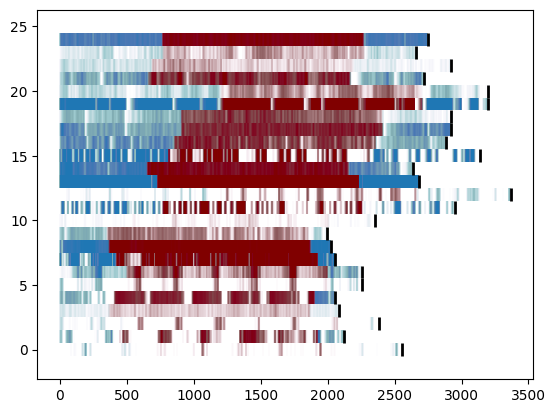

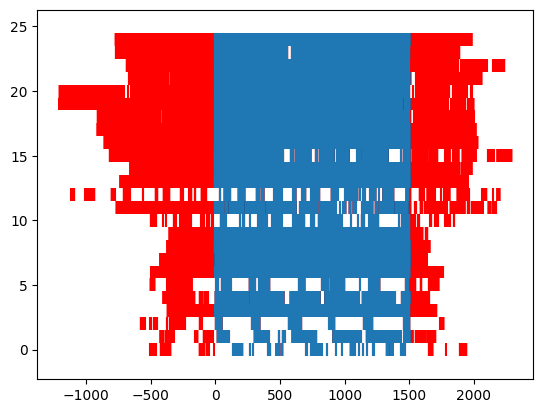

In [63]:
plt.eventplot([sp.magnitude for sp in spikes_df["OFF"]],linewidths=0.01)
plt.eventplot([[sp.t_stop.magnitude] for sp in spikes_df["OFF"]],color='black',linewidths=2)
plt.eventplot([sp.magnitude for sp in cut_spikes_df["OFF"]],linewidths=0.01,color='red')
plt.show()

zeroed_spikes = {
    cell_type: [sp.time_shift(-sp.t_start) for sp in cut_spikes_df[cell_type]] for cell_type in ["ON","OFF"]
}

zeroed_full_length_spikes = {
    cell_type: [sp.time_shift(-sp2.t_start) for sp,sp2 in zip(spikes_df[cell_type],cut_spikes_df[cell_type])] for cell_type in ["ON","OFF"]
}

plt.eventplot([sp.magnitude for sp in zeroed_full_length_spikes["OFF"]],color='red')
plt.eventplot([sp.magnitude for sp in zeroed_spikes["OFF"]])
plt.show()

t_starts = {
    "ON": [sp.t_start for sp in cut_spikes_ON],
    "OFF": [sp.t_start for sp in cut_spikes_OFF]
}
t_stops = {
    "ON": [sp.t_stop for sp in cut_spikes_ON],
    "OFF": [sp.t_stop for sp in cut_spikes_OFF]
}


Double checking the overlaying of the cut and uncut data.

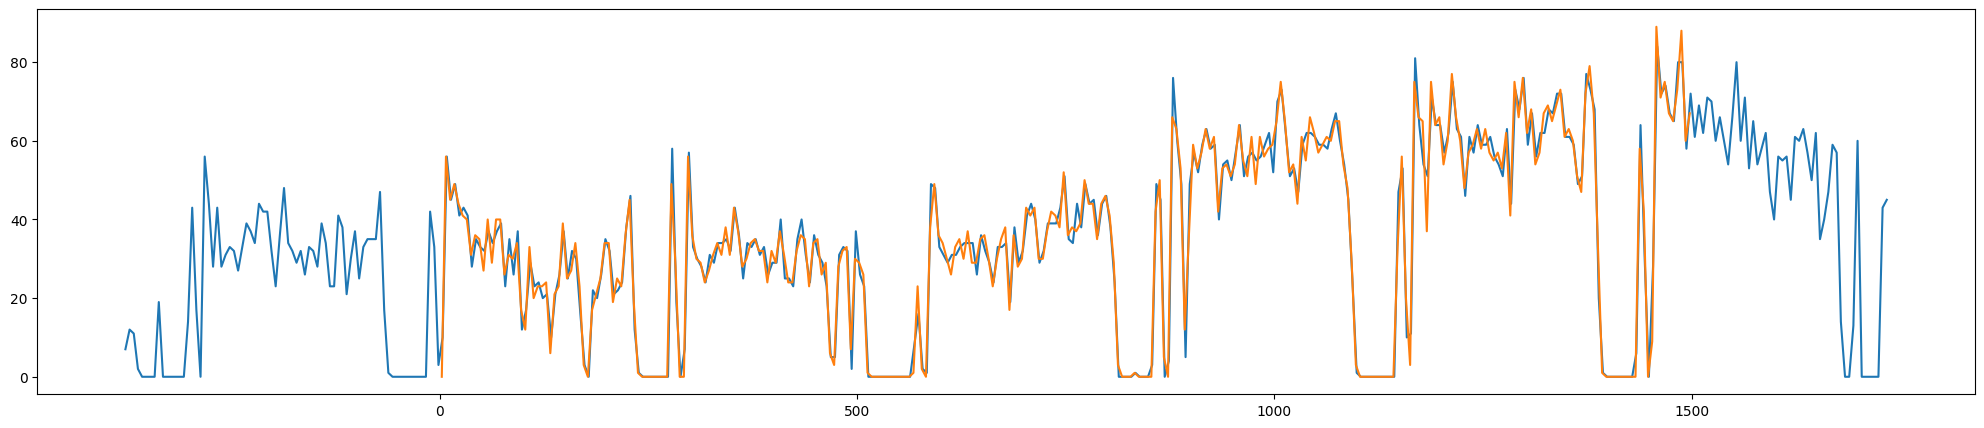

In [64]:
cut_time = 1500*s
bin_width = 5 *s


data = {
    cell_type: [BinnedSpikeTrain(
        sp, bin_size=bin_width,t_start=sp.t_start,t_stop=sp.t_stop,
    ) for sp in zeroed_spikes[cell_type]] for cell_type in ["ON","OFF"]
}

full_length_data = {
    cell_type: [BinnedSpikeTrain(
        sp, bin_size=bin_width, t_start=sp.t_start,t_stop=sp.t_stop
    ) for sp in zeroed_full_length_spikes[cell_type]] for cell_type in ["ON","OFF"]
}


def plot_overlaid_binned_spikes(index=0,cell_type="ON",ax=None):
    if ax is None:
        fig,ax = plt.subplots(figsize=(25,5))
    
    ax.plot(
        full_length_data[cell_type][index].bin_centers ,full_length_data[cell_type][index].to_array().T
    )
    ax.plot(
        data[cell_type][index].bin_centers ,data[cell_type][index].to_array().T
    )
    if ax is None:
        plt.show()

plot_overlaid_binned_spikes(6,"ON")

In [65]:
def find_maximum_x_time(train_x,mean_train)-> tuple[float,intp,float]:
    """ Finds the maximum value and time of maximum of the posterior mean GP samples."""
    argmax_mean = np.argmax(mean_train)
    max_time = train_x[argmax_mean]
    max_val = mean_train[argmax_mean]
    return max_time, argmax_mean, max_val

def find_minimum_x_time(train_x,mean_train)-> tuple[float,intp,float]:
    """ Finds the maximum value and time of maximum of the posterior mean GP samples."""
    argmin_mean = np.argmin(mean_train)
    min_time = train_x[argmin_mean]
    min_val = mean_train[argmin_mean]
    return min_time, argmin_mean, min_val

Now we gather the tail flick (TF) latencies in a dataframe to compare against the firing rates and phase in each trial.

In [66]:
TF_latencies_df = dm.get_all_firing_rate_type_TF_latency_tuples(-5*s,'All',mean_relative=False,flick_relative=False)
TF_clean = TF_latencies_df.groupby('file_origin', group_keys=False).apply(lambda x: x.drop_duplicates(subset='heat_index_in_cell'))
TF_clean

No corresponding flick, missing trains [26], event 2
169 viable trials


,cell_index,heat_index_in_cell,file_origin,train_index_from_dataset,cell_type,spiketrain,cut_spikes_pre_trial,mean_rate_pre_trial,TF_latency,heat_time
0,0,0,CA_ongoing01a_cut_pared,0,ON,"[0.0246792 s, 0.3675671999999999 s, 0.43321199...",[],0.0,8.442902,189.85201039999998 s
1,0,1,CA_ongoing01a_cut_pared,0,ON,"[0.0246792 s, 0.3675671999999999 s, 0.43321199...","[-4.942467400000169 s, -4.897539399999914 s, -...",9.8,10.090844,2083.094065 s
2,0,2,CA_ongoing01a_cut_pared,0,ON,"[0.0246792 s, 0.3675671999999999 s, 0.43321199...",[],0.0,8.257532,2262.5024941999995 s
3,0,3,CA_ongoing01a_cut_pared,0,ON,"[0.0246792 s, 0.3675671999999999 s, 0.43321199...",[],0.0,10.135190,2515.2516921999995 s
20,5,0,CA_ongoing01b_cut_pared,5,OFF,"[0.128739 s, 0.32832539999999993 s, 0.46033259...","[-4.876398799999997 s, -4.653256400000004 s, -...",4.6,8.521531,61.57307779999999 s
...,...,...,...,...,...,...,...,...,...,...
164,48,1,ZS Naive 5-2-24a OFF@2030_cut_pared,48,OFF,"[0.8580599999999999 s, 6.166092 s, 6.491627999...","[-4.504015999999865 s, -4.046319999999923 s, -...",1.6,9.701296,2272.251996 s
165,48,2,ZS Naive 5-2-24a OFF@2030_cut_pared,48,OFF,"[0.8580599999999999 s, 6.166092 s, 6.491627999...","[-4.940960000000359 s, -4.86736000000019 s, -4...",2.0,8.620424,2539.897324 s
166,49,0,ZS Naive 5-2-24b OFF@2632_cut_pared,49,OFF,"[0.034048 s, 0.10352 s, 0.18975999999999998 s,...","[-4.947732000000002 s, -4.851380000000006 s, -...",9.0,10.327412,234.107956 s
167,49,1,ZS Naive 5-2-24b OFF@2632_cut_pared,49,OFF,"[0.034048 s, 0.10352 s, 0.18975999999999998 s,...","[-4.9602279999999155 s, -4.870531999999912 s, ...",9.0,9.611028,2266.5193 s


In [67]:
def get_heat_times(cut_cell: neo.SpikeTrain,TF_clean):
    """
    Gets the withdrawal times corresponding to a spiketrain. Returns two ordered lists.
    A list of latencies, and a list of heat times.
    """
    origin = cut_cell.file_origin.split("\\")[-1] #type: ignore
    heat_delay_pairs: pd.DataFrame = TF_clean[TF_clean['file_origin'] == origin[:-5]][['TF_latency','heat_time']]
    heat_delay_pairs['heat_time'] = heat_delay_pairs['heat_time'].apply(lambda x: x.magnitude)
    return heat_delay_pairs

In [68]:
heat_times_and_latencies = {
    "ON": [],
    "OFF": [],
}

for cell_type in heat_times_and_latencies.keys():
    latency_time_phase_pairs = []
    for t_start, t_stop, cut_cell in zip(t_starts[cell_type],t_stops[cell_type], cut_spikes_df[cell_type]):
        heat_delay_pairs = get_heat_times(cut_cell,TF_clean)
        
        heat_times_and_latencies[cell_type].append((list(heat_delay_pairs['TF_latency']),list(heat_delay_pairs['heat_time'])))

heat_times_and_latencies

{'ON': [([8.442902000000004,
    10.090844400000151,
    8.257532399999945,
    10.135189999999966],
   [189.85201039999998, 2083.094065, 2262.5024941999995, 2515.2516921999995]),
  ([8.442902000000004,
    10.090844400000151,
    8.257532399999945,
    10.135189999999966],
   [189.85201039999998, 2083.094065, 2262.5024941999995, 2515.2516921999995]),
  ([8.442902000000004,
    10.090844400000151,
    8.257532399999945,
    10.135189999999966],
   [189.85201039999998, 2083.094065, 2262.5024941999995, 2515.2516921999995]),
  ([8.442902000000004,
    10.090844400000151,
    8.257532399999945,
    10.135189999999966],
   [189.85201039999998, 2083.094065, 2262.5024941999995, 2515.2516921999995]),
  ([9.5342312], [61.69145059999999]),
  ([9.5342312], [61.69145059999999]),
  ([6.469057399999997, 8.076510000000098, 9.997608400000445],
   [35.9444696, 1879.0016829999997, 2064.8656651999995]),
  ([7.386717000000001, 6.448907400000053, 11.511731399999917],
   [16.895769799999997, 1974.3544625999

In [69]:
def get_withdrawal_times_and_latency(cell_type,index):
    return heat_times_and_latencies[cell_type][index][0],heat_times_and_latencies[cell_type][index][1]
            

In [70]:
def plot_training_results(train_x, train_y, test_x, test_y,
                          latent_test_func_quantiles, latent_train_func_quantiles,
                          cell_name, index,quantiles_with_noise,quantiles_with_noise_training,mean_withdrawal_rates,
                          fontsize=7):
    """
    Plots the training results for a cell over test and training data.

    Parameters:
    - train_x, train_y: training data
    - test_x, test_y: test data
    - latent_percentiles: (lower, mean, upper) for test predictions
    - latent_training_percentiles: (lower, mean, upper) for train predictions
    - y_sim: sample from the model (unused now)
    - cell_name, index: identifiers for the plot (unused here)
    - fontsize: unified font size for labels and legend
    """
    lower, mean, upper = latent_test_func_quantiles
    lower_train, mean_train, upper_train = latent_train_func_quantiles
    lower_poisson_test, mean_poisson_test, upper_poisson_test = quantiles_with_noise
    lower_poisson_train, mean_poisson_train, upper_poisson_train = quantiles_with_noise_training

    plt.rcParams['axes.linewidth'] = 0.5
    plt.rcParams['font.size'] = 7
    plt.rcParams['xtick.labelsize'] = 7
    plt.rcParams['ytick.labelsize'] = 7
    fig, ax = plt.subplots(figsize=(8, 2))

    # GP predictions with uncertainty for test data
    ax.plot(test_x, mean, color='black',linestyle=(0,(1,1)),linewidth=0.7)
    # ax.plot(test_x, mean_poisson_test, label='GP Likelihood test prediction', color='red')
    # ax.plot(train_x, mean_poisson_train, label='GP Likelihood train prediction', color='blue')
    ax.fill_between(
        test_x,
        lower,
        upper,
        color='slategray', alpha=0.4
    )

    # GP predictions with uncertainty for train data
    ax.plot(train_x, mean_train, label='Predicted Mean', color='black',linewidth=0.7)
    
    max_time, _, _ = find_maximum_x_time(train_x,mean_train)
    min_time, _, _ = find_minimum_x_time(train_x,mean_train)
    

    ax.fill_between(
        train_x,
        lower_train,
        upper_train,
        color='slategray', alpha=0.4,label="95% Mean CI"
    )

    ax.fill_between(
        test_x,
        lower_poisson_test,
        upper_poisson_test,
        color='gray', alpha=0.2,label="95% Observation CI"
    )

    ax.fill_between(
        train_x,
        lower_poisson_train,
        upper_poisson_train,
        color='gray', alpha=0.2
    )

    ax.scatter(test_x, test_y, alpha=0.8, color=get_cell_colour(names=cell_name),marker='x',s=10)

    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)
    
    ax.tick_params(which='both',left=True, bottom=True, labelbottom=True,labelsize=fontsize,width=0.5,length=2)

    ax.set_xlabel("Time(s)", fontsize=fontsize,labelpad=1)
    ax.set_ylabel("Spike Count", fontsize=fontsize,labelpad=1)
    ax.grid(False)


    plt.vlines(max_time,0,250)
    plt.vlines(min_time,0,250,color='red')

    latencies_for_cell, heat_times = get_withdrawal_times_and_latency(cell_name,index)
    plt.vlines(heat_times - cut_spikes_df[cell_name][index].t_start.magnitude,0,250,color='purple',label="heat_times")
    plt.scatter(heat_times - cut_spikes_df[cell_name][index].t_start.magnitude,mean_withdrawal_rates,s=30,c='blue')



    ax.set_xlim(ax.get_xlim()[0]-5,ax.get_xlim()[1] + 5)

    save_in_folder(f"{cell_name}_GP_fit",svg=True,save=True)

In [71]:
scale = torch.tensor(10.0)

In [72]:

def nonlinearity(nonlinear_func):
    """ Useful so that I can choose different link function but only change one line of code."""
    return lambda f: nonlinear_func(f)

softplus = torch.nn.Softplus(beta=1,threshold=20)
link_function = nonlinearity(softplus)

In [ ]:
def get_gen_poiss_samples(model,test_x,train_x,w,model_mean=False,num_samples=200):
    """
    Returns four tuples of values:
    - Test x function 2.5 percent, mean, 97.5 percent
    - Test x sample 2.5 percent, mean, 97.5 percent
    - Train x function 2.5 percent, mean, 97.5 percent
    - Test x sample 2.5 percent, mean, 97.5 percent
    """
    model.eval()
    with torch.no_grad():
        outputs = [model(test_x),model(train_x)] #* Do test then train
        lower_mean_upper: list[list] = []
        for output in outputs:
            rng = np.random.default_rng()

            num_samples = num_samples
            f_samples = output.sample(torch.Size([num_samples]))

            # lambda_samples = torch.exp(f_samples)
            lambda_samples = scale * link_function(f_samples)
            if model_mean:
                mean_samples = lambda_samples
            else:
                mean_samples = lambda_samples / (1-w)

            # Get samples of the mean of the GP fit.
            lower, upper = [np.percentile(mean_samples, p, axis=0) for p in [2.5,97.5]]

            lower_mean_upper.append([lower,mean_samples.mean(axis=0),upper])

            k_vals = np.arange(0, 2000)

            count_samples = np.zeros((num_samples, lambda_samples.shape[1]))

            # Get samples from the spike count of the GP fit.
            for i in range(num_samples):
                for j in range(lambda_samples.shape[1]):
                    if model_mean == True:
                        param_samples = lambda_samples[i, j].item() * (1-w)
                    else:
                        param_samples = lambda_samples[i,j].item()
                    count_samples[i, j] = generalized_poisson_sample(param_samples,
                                                                     alpha=w,
                                                                     k_vals=k_vals, rng=rng)

            lower, upper = [np.percentile(count_samples, p, axis=0) for p in [2.5,97.5]]
            lower_mean_upper.append([lower,count_samples.mean(axis=0),upper])
    return lower_mean_upper

In [ ]:
def evaluate_model(model,likelihood,test_x,train_x,test_y,train_y,model_index,mean_withdrawal_rates,cell_name,plot=True,model_mean=False,plot_CI_samples=200):

    with torch.no_grad(),gpytorch.settings.fast_pred_var():

        latent_percents,quantiles_with_noise,latent_percents_train,quantiles_with_noise_training = get_gen_poiss_samples(
            model=model,
            test_x=test_x,
            train_x=train_x,
            w=likelihood.alpha.numpy(),
            model_mean=model_mean,
            num_samples=plot_CI_samples
            )
        if plot:
            plot_training_results(
                train_x, train_y, test_x, test_y,
                latent_percents,
                latent_percents_train,
                cell_name,model_index, quantiles_with_noise
                ,quantiles_with_noise_training,mean_withdrawal_rates,fontsize=7,
            )
        lower, mean_train, upper = latent_percents_train
        return find_maximum_x_time(train_x,mean_train), find_minimum_x_time(train_x,mean_train)

In [ ]:
def set_mean_and_scale(model,likelihood,train_y,has_scale=True):
    """Sets the mean and scale for the GP model."""
    model.mean_module.constant = (train_y.max()+train_y.min()) * (1-likelihood.alpha.item())/2 / scale
    if has_scale:
        model.main_scale = train_y.var()/100
        print("initial scale:", model.main_scale, "sqrt",torch.sqrt(model.main_scale))

In [ ]:
def create_model(T_min,T_max, max_count,num_data,num_inducing=200,model_mean=False):
    """
    Creates a copy of the Poisson GP model, to which the fitted parameters will be assigned later.
    """
    model = PeriodicGPModel(T_min=T_min,T_max=T_max,num_inducing=num_inducing)
    likelihood = PoissonUniformMixtureLikelihood(uniform_max=int(max_count),model_mean=model_mean)
    mll = gpytorch.mlls.VariationalELBO(likelihood, model, num_data=num_data)
    return model, likelihood, mll

In [ ]:
def predict_firing_rate_at_heat_onset_times(model, likelihood,train_x,test_x,withdrawal_times,model_mean,plot_CI_samples):
    """Predicts the GP rate at the time of heat application to the hind paw in a trial."""
    print("predicting at heat times:", withdrawal_times)

    test_x = torch.tensor(withdrawal_times,requires_grad=False)

    latent_percents,quantiles_with_noise,latent_percents_train,quantiles_with_noise_training = get_gen_poiss_samples(
        model,test_x,train_x,likelihood.alpha.detach().numpy(),model_mean=model_mean,num_samples=plot_CI_samples)
    
    withdrawal_rate_stats = latent_percents
    return withdrawal_rate_stats

In [ ]:
def fit_all_cells_using_prior_gp_fit_data(data, base_save_dir, num_iter,
                                         num_inducing, save_params=False,save_results=False,from_last=True,max_count=100,lr=0.1,
                                         cell_ids: list=None, compare_mean=True,model_mean=False,retrain_mean=False,plot_CI_samples=200):
    """
    Fit a Poisson GP model for each cell and save R², key params, and full model param store.
    """
    
    loss_histories = {}
    max_times = defaultdict(lambda: [])
    periods = defaultdict(lambda: [])
    withdrawal_rates_dict = defaultdict(lambda: [])
    latencies = defaultdict(lambda: [])
    
    for (cell_name, cell_data) in data.items():
    

        for i, binned_spike_train in enumerate(cell_data):
            binned_spike_train: BinnedSpikeTrain = binned_spike_train

            train_x = torch.from_numpy(binned_spike_train.bin_centers.magnitude).float()
            
            train_y = torch.from_numpy(binned_spike_train.to_array()).float()

            test_x = torch.from_numpy(full_length_data[cell_name][i].bin_centers.magnitude).float()
            
            test_y = torch.from_numpy(full_length_data[cell_name][i].to_array()).float()

            model_id = f"{cell_name}_{i}"
            T_max = torch.max(train_x)
            T_min = torch.min(train_x)

            if cell_ids is not None:
                if model_id not in cell_ids:
                    continue
            print(model_id)
            model_param_path = os.path.join(base_save_dir, "saved_models", f"{model_id}_model_params.pt")
            lik_param_path = os.path.join(base_save_dir, "saved_models", f"{model_id}_likelihood_params.pt")

            if from_last:
                if os.path.exists(
                    os.path.join(base_save_dir,"saved_models",f"{model_id}_model_params.pt")
                    ):
                    continue

            model, likelihood, mll = create_model(T_min,T_max, max_count=max_count,num_data = train_y.size(0),num_inducing=num_inducing,
                                                  model_mean=model_mean)
            
            print("alpha_init: ",likelihood.alpha.item(),"output_scale_init: ", model.main_scale)
            set_mean_and_scale(model,likelihood,train_y,has_scale=True)


            # Load the model pararameters
            if not os.path.exists(model_param_path):
                raise FileNotFoundError(f"Saved model not found at {model_param_path}")
            model.load_state_dict(torch.load(model_param_path))
            likelihood.load_state_dict(torch.load(lik_param_path))

            
            latencies_for_cell, heat_times = get_withdrawal_times_and_latency(cell_name,i)

            lower,mean_withdrawal_rates,upper = predict_firing_rate_at_heat_onset_times(
                model=model,
                likelihood=likelihood,
                train_x=train_x,
                test_x=test_x,
                withdrawal_times=heat_times- cut_spikes_df[cell_name][i].t_start.magnitude,
                model_mean=model_mean,
                plot_CI_samples=plot_CI_samples
            )

            (max_time, argmax_mean, max_val),(min_time, argmin_mean, min_val) = evaluate_model(
                model,likelihood,test_x,train_x,test_y,train_y,i,mean_withdrawal_rates,
                cell_name=cell_name,model_mean=model_mean,plot_CI_samples=50 #! Leave small for plotting.,
                )
            

            max_times[cell_name].append(max_time)
            model: PeriodicGPModel = model


            
            #Normalize withdrawal rates
            withdrawal_rates = (mean_withdrawal_rates - min_val) / (max_val - min_val)

            if max_val - min_val > 1:
                print("rates: ", withdrawal_rates)
                withdrawal_rates_dict[cell_name].append(withdrawal_rates)
            else:
                withdrawal_rates_dict[cell_name].append(np.NaN)
                print("Not enough variance in fitted GP")
            latencies[cell_name].append(latencies_for_cell)

            
            periods[cell_name].append(model.per_scale.base_kernel.period_length)
                
    return max_times, periods, withdrawal_rates_dict,latencies

ON_0
alpha_init:  1.1102230246251565e-16 output_scale_init:  tensor(0.6931, grad_fn=<SoftplusBackward0>)
initial scale: tensor(5.8664, grad_fn=<SoftplusBackward0>) sqrt tensor(2.4221, grad_fn=<SqrtBackward0>)
predicting at heat times: [-393.2420546 1500.        1679.4084292 1932.1576272]


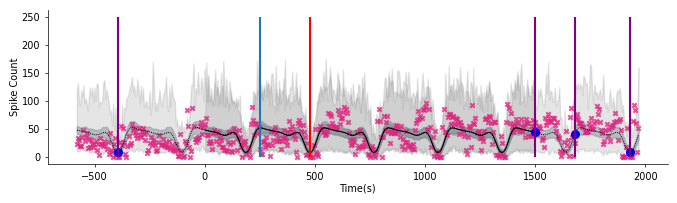

rates:  tensor([0.0095, 0.8249, 0.7409, 0.0091])
ON_1
alpha_init:  1.1102230246251565e-16 output_scale_init:  tensor(0.6931, grad_fn=<SoftplusBackward0>)
initial scale: tensor(6.3154, grad_fn=<SoftplusBackward0>) sqrt tensor(2.5130, grad_fn=<SqrtBackward0>)
predicting at heat times: [-393.2420546 1500.        1679.4084292 1932.1576272]


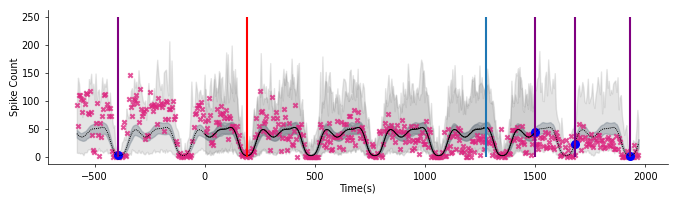

rates:  tensor([0.0060, 0.8540, 0.4099, 0.0020])
ON_2
alpha_init:  1.1102230246251565e-16 output_scale_init:  tensor(0.6931, grad_fn=<SoftplusBackward0>)
initial scale: tensor(23.2586, grad_fn=<SoftplusBackward0>) sqrt tensor(4.8227, grad_fn=<SqrtBackward0>)
predicting at heat times: [-393.2420546 1500.        1679.4084292 1932.1576272]


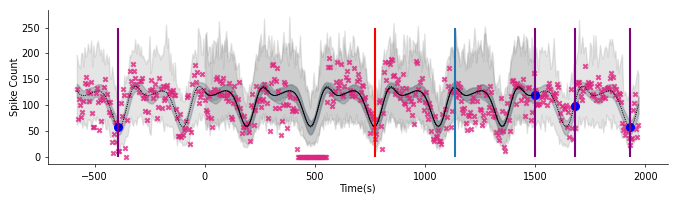

rates:  tensor([-0.0154,  0.8205,  0.5320, -0.0225])
ON_3
alpha_init:  1.1102230246251565e-16 output_scale_init:  tensor(0.6931, grad_fn=<SoftplusBackward0>)
initial scale: tensor(0.4627, grad_fn=<SoftplusBackward0>) sqrt tensor(0.6802, grad_fn=<SqrtBackward0>)
predicting at heat times: [-393.2420546 1500.        1679.4084292 1932.1576272]


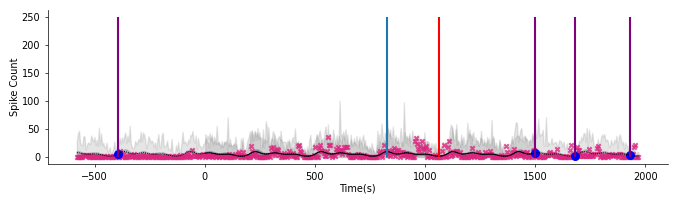

rates:  tensor([0.4860, 0.6725, 0.0940, 0.1560])
ON_4
alpha_init:  1.1102230246251565e-16 output_scale_init:  tensor(0.6931, grad_fn=<SoftplusBackward0>)
initial scale: tensor(8.2449, grad_fn=<SoftplusBackward0>) sqrt tensor(2.8714, grad_fn=<SqrtBackward0>)
predicting at heat times: [-238.3085494]


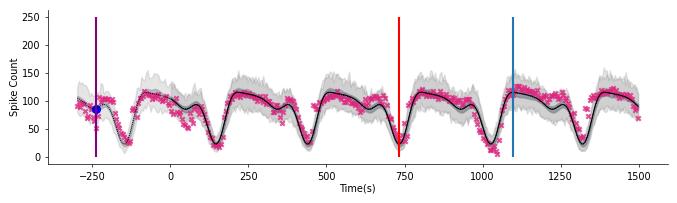

rates:  tensor([0.6754])
ON_5
alpha_init:  1.1102230246251565e-16 output_scale_init:  tensor(0.6931, grad_fn=<SoftplusBackward0>)
initial scale: tensor(3.6650, grad_fn=<SoftplusBackward0>) sqrt tensor(1.9144, grad_fn=<SqrtBackward0>)
predicting at heat times: [-238.3085494]


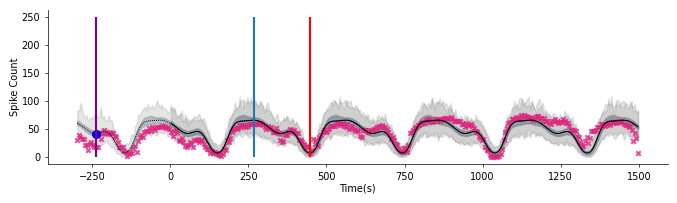

rates:  tensor([0.5890])
ON_6
alpha_init:  1.1102230246251565e-16 output_scale_init:  tensor(0.6931, grad_fn=<SoftplusBackward0>)
initial scale: tensor(5.3263, grad_fn=<SoftplusBackward0>) sqrt tensor(2.3079, grad_fn=<SqrtBackward0>)
predicting at heat times: [-343.0572134 1500.        1685.8639822]


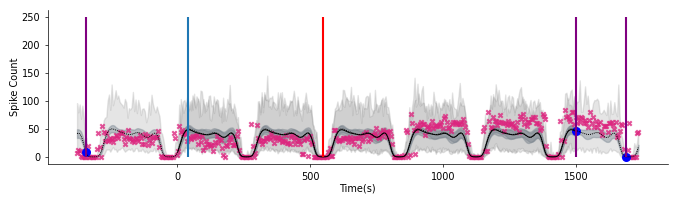

rates:  tensor([0.1763, 0.9610, 0.0077])
ON_7
alpha_init:  1.1102230246251565e-16 output_scale_init:  tensor(0.6931, grad_fn=<SoftplusBackward0>)
initial scale: tensor(96.1639, grad_fn=<SoftplusBackward0>) sqrt tensor(9.8063, grad_fn=<SqrtBackward0>)
predicting at heat times: [-457.4586928 1500.        1547.7111154]


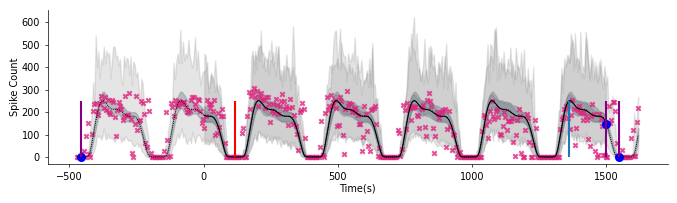

rates:  tensor([1.2950e-04, 5.8602e-01, 7.9112e-04])
ON_8
alpha_init:  1.1102230246251565e-16 output_scale_init:  tensor(0.6931, grad_fn=<SoftplusBackward0>)
initial scale: tensor(13.4570, grad_fn=<SoftplusBackward0>) sqrt tensor(3.6684, grad_fn=<SqrtBackward0>)
predicting at heat times: [-457.4586928 1500.        1547.7111154]


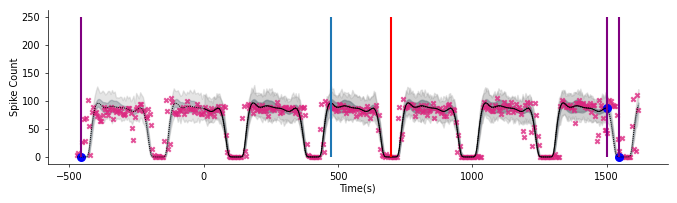

rates:  tensor([1.1545e-05, 8.9759e-01, 5.5846e-04])
ON_9
alpha_init:  1.1102230246251565e-16 output_scale_init:  tensor(0.6931, grad_fn=<SoftplusBackward0>)
initial scale: tensor(13.5988, grad_fn=<SoftplusBackward0>) sqrt tensor(3.6877, grad_fn=<SqrtBackward0>)
predicting at heat times: [-233.5039462 1500.        1688.6022658]


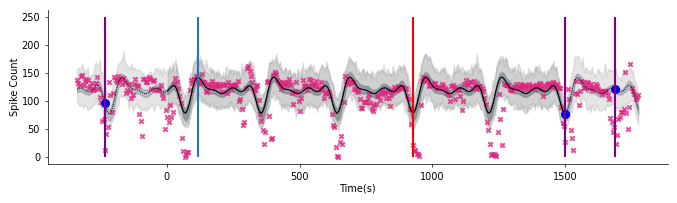

rates:  tensor([ 0.2654, -0.0312,  0.6789])
ON_10
alpha_init:  1.1102230246251565e-16 output_scale_init:  tensor(0.6931, grad_fn=<SoftplusBackward0>)
initial scale: tensor(2.3894, grad_fn=<SoftplusBackward0>) sqrt tensor(1.5458, grad_fn=<SqrtBackward0>)
predicting at heat times: [-399.627327  -281.9063002 1500.        1607.2125418]


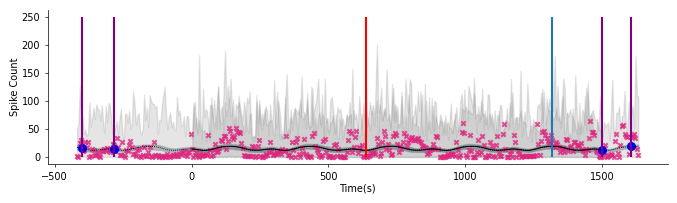

rates:  tensor([0.4860, 0.2811, 0.1296, 0.9964])
ON_11
alpha_init:  1.1102230246251565e-16 output_scale_init:  tensor(0.6931, grad_fn=<SoftplusBackward0>)
initial scale: tensor(16.2098, grad_fn=<SoftplusBackward0>) sqrt tensor(4.0261, grad_fn=<SqrtBackward0>)
predicting at heat times: [-228.5730202 1500.        1801.0575334]


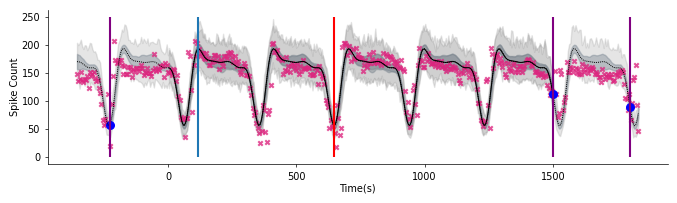

rates:  tensor([0.0070, 0.4156, 0.2415])
ON_12
alpha_init:  1.1102230246251565e-16 output_scale_init:  tensor(0.6931, grad_fn=<SoftplusBackward0>)
initial scale: tensor(0.0026, grad_fn=<SoftplusBackward0>) sqrt tensor(0.0509, grad_fn=<SqrtBackward0>)
predicting at heat times: [-228.5730202 1500.        1801.0575334]


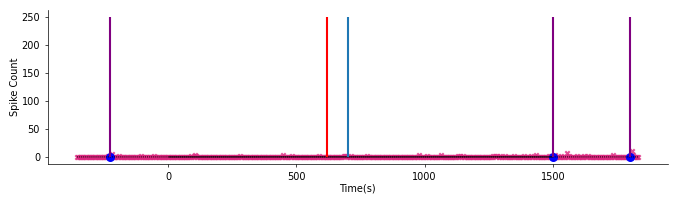

Not enough variance in fitted GP
ON_13
alpha_init:  1.1102230246251565e-16 output_scale_init:  tensor(0.6931, grad_fn=<SoftplusBackward0>)
initial scale: tensor(3.0364, grad_fn=<SoftplusBackward0>) sqrt tensor(1.7425, grad_fn=<SqrtBackward0>)
predicting at heat times: [-226.4810992 1500.        1762.5834952 1817.9903064]


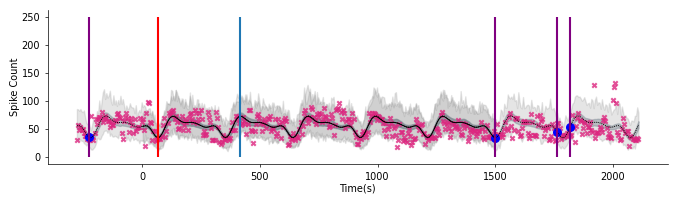

rates:  tensor([ 0.0211, -0.0181,  0.2803,  0.5004])
ON_14
alpha_init:  1.1102230246251565e-16 output_scale_init:  tensor(0.6931, grad_fn=<SoftplusBackward0>)
initial scale: tensor(6.7095, grad_fn=<SoftplusBackward0>) sqrt tensor(2.5903, grad_fn=<SqrtBackward0>)
predicting at heat times: [-226.4810992 1500.        1762.5834952 1817.9903064]


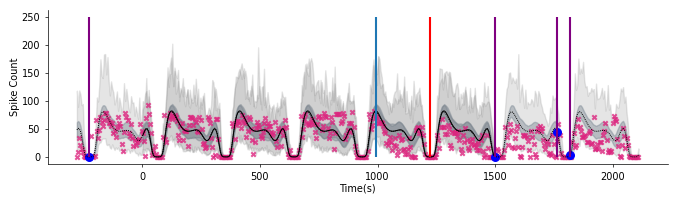

rates:  tensor([1.6474e-04, 5.1852e-03, 5.3603e-01, 3.1300e-02])
ON_15
alpha_init:  1.1102230246251565e-16 output_scale_init:  tensor(0.6931, grad_fn=<SoftplusBackward0>)
initial scale: tensor(30.6292, grad_fn=<SoftplusBackward0>) sqrt tensor(5.5344, grad_fn=<SqrtBackward0>)
predicting at heat times: [-322.981204 1791.253148 2090.818204]


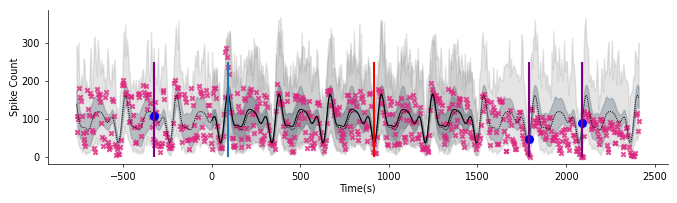

rates:  tensor([0.5555, 0.0752, 0.4059])
ON_16
alpha_init:  1.1102230246251565e-16 output_scale_init:  tensor(0.6931, grad_fn=<SoftplusBackward0>)
initial scale: tensor(17.2493, grad_fn=<SoftplusBackward0>) sqrt tensor(4.1532, grad_fn=<SqrtBackward0>)
predicting at heat times: [-374.014576 1500.       1796.862076]


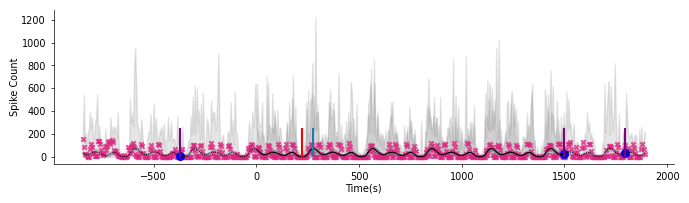

rates:  tensor([0.0865, 0.3728, 0.4746])
ON_17
alpha_init:  1.1102230246251565e-16 output_scale_init:  tensor(0.6931, grad_fn=<SoftplusBackward0>)
initial scale: tensor(1.4968, grad_fn=<SoftplusBackward0>) sqrt tensor(1.2235, grad_fn=<SqrtBackward0>)
predicting at heat times: [-277.166644 1500.       1776.648948 2002.167684]


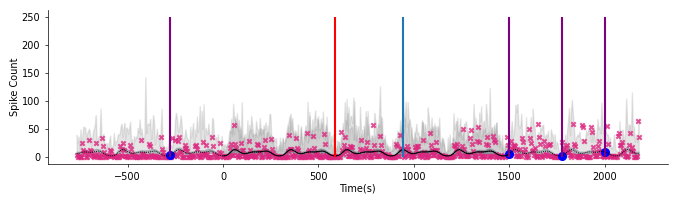

rates:  tensor([0.0697, 0.3408, 0.0459, 0.6950])
ON_18
alpha_init:  1.1102230246251565e-16 output_scale_init:  tensor(0.6931, grad_fn=<SoftplusBackward0>)
initial scale: tensor(15.3185, grad_fn=<SoftplusBackward0>) sqrt tensor(3.9139, grad_fn=<SqrtBackward0>)
predicting at heat times: [-433.241776 1500.       1855.19082  2130.836588]


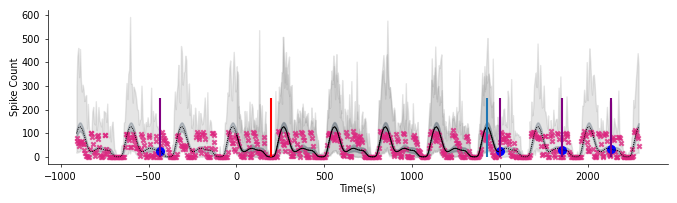

rates:  tensor([0.1953, 0.1826, 0.2354, 0.2651])
ON_19
alpha_init:  1.1102230246251565e-16 output_scale_init:  tensor(0.6931, grad_fn=<SoftplusBackward0>)
initial scale: tensor(15.8117, grad_fn=<SoftplusBackward0>) sqrt tensor(3.9764, grad_fn=<SqrtBackward0>)
predicting at heat times: [-868.871312 -376.908428 1500.       1806.465332 2120.340872]


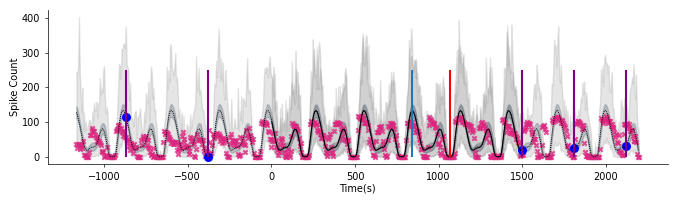

rates:  tensor([8.6862e-01, 1.9514e-05, 1.5109e-01, 1.9654e-01, 2.4146e-01])
ON_20
alpha_init:  1.1102230246251565e-16 output_scale_init:  tensor(0.6931, grad_fn=<SoftplusBackward0>)
initial scale: tensor(37.4932, grad_fn=<SoftplusBackward0>) sqrt tensor(6.1232, grad_fn=<SqrtBackward0>)
predicting at heat times: [-414.028852 1500.       1807.966416]


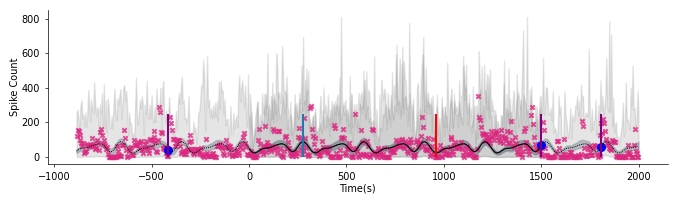

rates:  tensor([0.2530, 0.6657, 0.5643])
ON_21
alpha_init:  1.1102230246251565e-16 output_scale_init:  tensor(0.6931, grad_fn=<SoftplusBackward0>)
initial scale: tensor(0.0441, grad_fn=<SoftplusBackward0>) sqrt tensor(0.2099, grad_fn=<SqrtBackward0>)
predicting at heat times: [-349.910544 1500.       1882.808692]


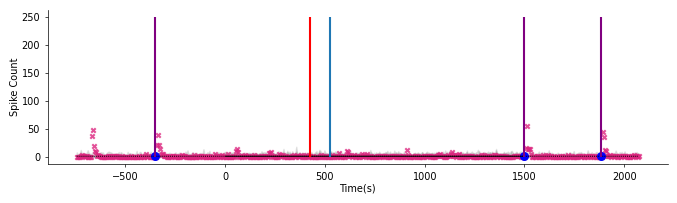

Not enough variance in fitted GP
ON_22
alpha_init:  1.1102230246251565e-16 output_scale_init:  tensor(0.6931, grad_fn=<SoftplusBackward0>)
initial scale: tensor(7.8871, grad_fn=<SoftplusBackward0>) sqrt tensor(2.8084, grad_fn=<SqrtBackward0>)
predicting at heat times: [-355.326248 1500.       1802.66478 ]


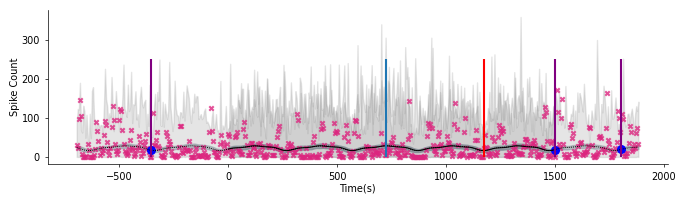

rates:  tensor([0.1076, 0.2227, 0.2351])
ON_23
alpha_init:  1.1102230246251565e-16 output_scale_init:  tensor(0.6931, grad_fn=<SoftplusBackward0>)
initial scale: tensor(2.9801, grad_fn=<SoftplusBackward0>) sqrt tensor(1.7263, grad_fn=<SqrtBackward0>)
predicting at heat times: [-369.029276 1500.       1803.764148]


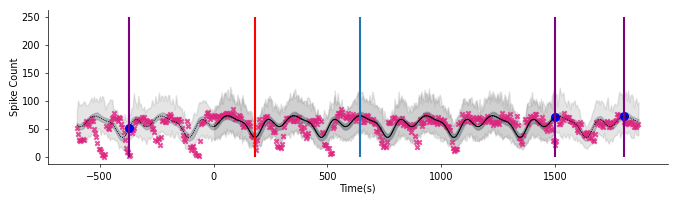

rates:  tensor([0.4339, 0.9437, 0.9967])
ON_24
alpha_init:  1.1102230246251565e-16 output_scale_init:  tensor(0.6931, grad_fn=<SoftplusBackward0>)
initial scale: tensor(0.3137, grad_fn=<SoftplusBackward0>) sqrt tensor(0.5601, grad_fn=<SqrtBackward0>)
predicting at heat times: [-377.23772  1500.       1800.969276]


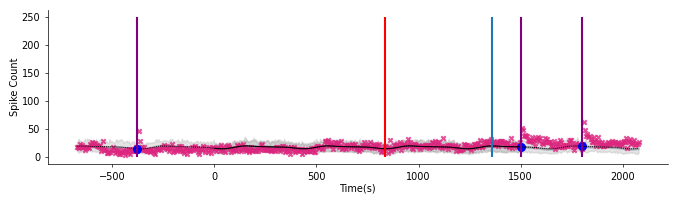

rates:  tensor([0.0046, 0.6908, 0.8202])
OFF_0
alpha_init:  1.1102230246251565e-16 output_scale_init:  tensor(0.6931, grad_fn=<SoftplusBackward0>)
initial scale: tensor(0.1301, grad_fn=<SoftplusBackward0>) sqrt tensor(0.3607, grad_fn=<SqrtBackward0>)
predicting at heat times: [-393.2420546 1500.        1679.4084292 1932.1576272]


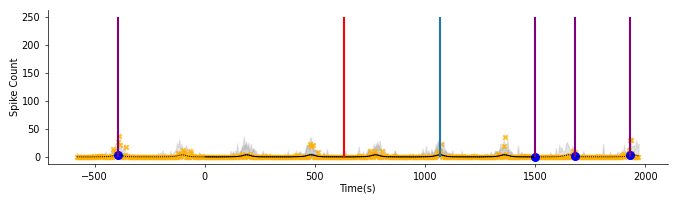

rates:  tensor([ 0.9377, -0.0014,  0.3585,  0.7457])
OFF_1
alpha_init:  1.1102230246251565e-16 output_scale_init:  tensor(0.6931, grad_fn=<SoftplusBackward0>)
initial scale: tensor(2.3719, grad_fn=<SoftplusBackward0>) sqrt tensor(1.5401, grad_fn=<SqrtBackward0>)
predicting at heat times: [-362.9669448 1500.        1606.6959764]


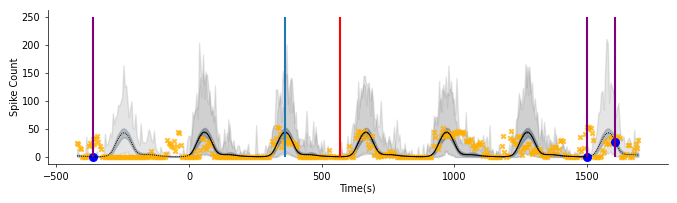

rates:  tensor([0.0023, 0.0080, 0.5815])
OFF_2
alpha_init:  1.1102230246251565e-16 output_scale_init:  tensor(0.6931, grad_fn=<SoftplusBackward0>)
initial scale: tensor(0.3514, grad_fn=<SoftplusBackward0>) sqrt tensor(0.5928, grad_fn=<SqrtBackward0>)
predicting at heat times: [-554.8723    1500.        1755.5565168]


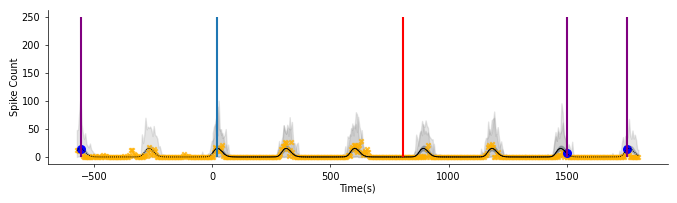

rates:  tensor([0.9831, 0.4458, 0.9038])
OFF_3
alpha_init:  1.1102230246251565e-16 output_scale_init:  tensor(0.6931, grad_fn=<SoftplusBackward0>)
initial scale: tensor(0.0736, grad_fn=<SoftplusBackward0>) sqrt tensor(0.2714, grad_fn=<SqrtBackward0>)
predicting at heat times: [-334.907594  1500.        1627.6017288]


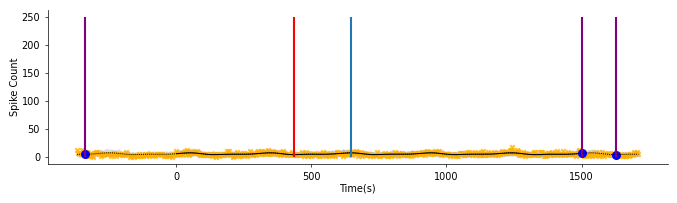

rates:  tensor([ 0.1976,  0.7190, -0.0012])
OFF_4
alpha_init:  1.1102230246251565e-16 output_scale_init:  tensor(0.6931, grad_fn=<SoftplusBackward0>)
initial scale: tensor(2.1206, grad_fn=<SoftplusBackward0>) sqrt tensor(1.4562, grad_fn=<SqrtBackward0>)
predicting at heat times: [-310.478592  1500.        1569.3091828]


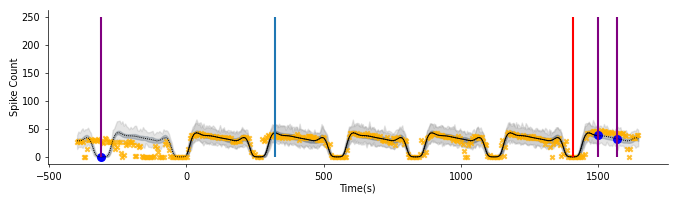

rates:  tensor([2.5544e-04, 8.9604e-01, 7.6341e-01])
OFF_5
alpha_init:  1.1102230246251565e-16 output_scale_init:  tensor(0.6931, grad_fn=<SoftplusBackward0>)
initial scale: tensor(0.4839, grad_fn=<SoftplusBackward0>) sqrt tensor(0.6956, grad_fn=<SqrtBackward0>)
predicting at heat times: [-475.390482  1500.        1533.4364446 1723.1149154]


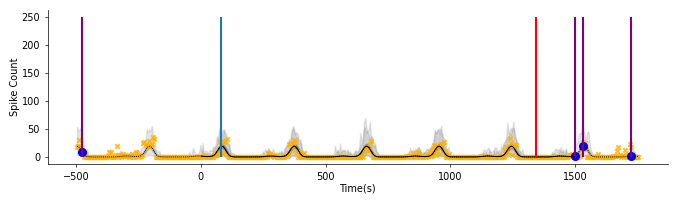

rates:  tensor([0.4353, 0.1208, 0.9883, 0.0863])
OFF_6
alpha_init:  1.1102230246251565e-16 output_scale_init:  tensor(0.6931, grad_fn=<SoftplusBackward0>)
initial scale: tensor(2.1383, grad_fn=<SoftplusBackward0>) sqrt tensor(1.4623, grad_fn=<SqrtBackward0>)
predicting at heat times: [-475.390482  1500.        1533.4364446 1723.1149154]


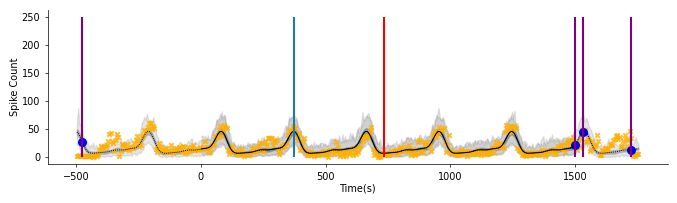

rates:  tensor([0.5123, 0.3826, 0.9889, 0.1467])
OFF_7
alpha_init:  1.1102230246251565e-16 output_scale_init:  tensor(0.6931, grad_fn=<SoftplusBackward0>)
initial scale: tensor(20.1415, grad_fn=<SoftplusBackward0>) sqrt tensor(4.4879, grad_fn=<SqrtBackward0>)
predicting at heat times: [-399.627327  -281.9063002 1500.        1607.2125418]


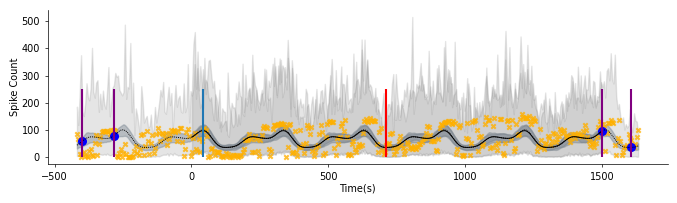

rates:  tensor([0.3856, 0.6966, 0.9537, 0.0139])
OFF_8
alpha_init:  1.1102230246251565e-16 output_scale_init:  tensor(0.6931, grad_fn=<SoftplusBackward0>)
initial scale: tensor(0.2156, grad_fn=<SoftplusBackward0>) sqrt tensor(0.4643, grad_fn=<SqrtBackward0>)
predicting at heat times: [-286.6430452 1500.        1620.2978556]


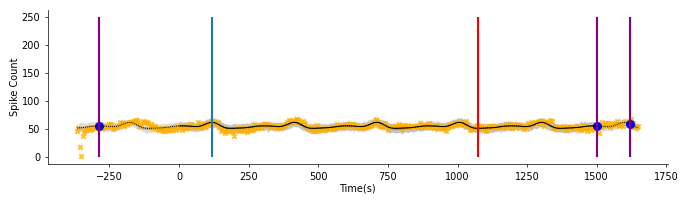

rates:  tensor([0.4086, 0.3999, 0.6935])
OFF_9
alpha_init:  1.1102230246251565e-16 output_scale_init:  tensor(0.6931, grad_fn=<SoftplusBackward0>)
initial scale: tensor(0.4690, grad_fn=<SoftplusBackward0>) sqrt tensor(0.6849, grad_fn=<SqrtBackward0>)
predicting at heat times: [-329.2825512 1500.        1594.8786384]


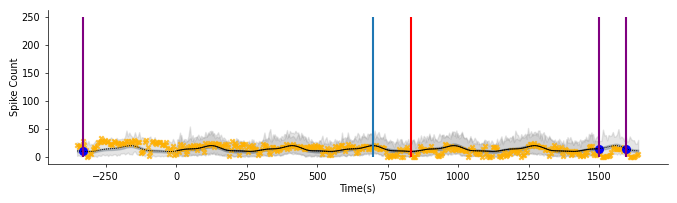

rates:  tensor([0.0160, 0.4712, 0.4916])
OFF_10
alpha_init:  1.1102230246251565e-16 output_scale_init:  tensor(0.6931, grad_fn=<SoftplusBackward0>)
initial scale: tensor(0.0295, grad_fn=<SoftplusBackward0>) sqrt tensor(0.1718, grad_fn=<SqrtBackward0>)
predicting at heat times: [-464.593579  1500.        1808.4721536]


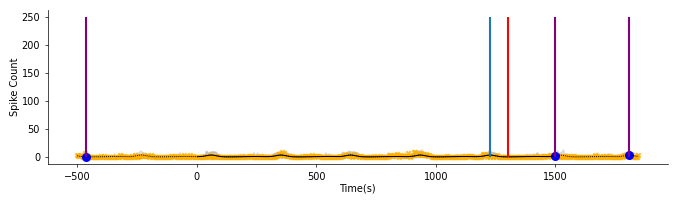

rates:  tensor([0.0350, 0.6905, 1.0078])
OFF_11
alpha_init:  1.1102230246251565e-16 output_scale_init:  tensor(0.6931, grad_fn=<SoftplusBackward0>)
initial scale: tensor(5.7757, grad_fn=<SoftplusBackward0>) sqrt tensor(2.4033, grad_fn=<SqrtBackward0>)
predicting at heat times: [-277.166644 1500.       1776.648948 2002.167684]


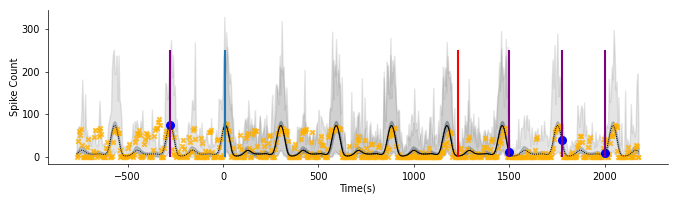

rates:  tensor([1.0197, 0.1225, 0.5171, 0.0957])
OFF_12
alpha_init:  1.1102230246251565e-16 output_scale_init:  tensor(0.6931, grad_fn=<SoftplusBackward0>)
initial scale: tensor(0.5620, grad_fn=<SoftplusBackward0>) sqrt tensor(0.7497, grad_fn=<SqrtBackward0>)
predicting at heat times: [-868.871312 -376.908428 1500.       1806.465332 2120.340872]


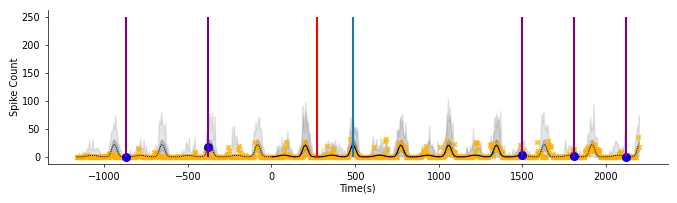

rates:  tensor([9.6001e-05, 8.8727e-01, 1.4396e-01, 1.1684e-01, 2.9266e-02])
OFF_13
alpha_init:  1.1102230246251565e-16 output_scale_init:  tensor(0.6931, grad_fn=<SoftplusBackward0>)
initial scale: tensor(14.3619, grad_fn=<SoftplusBackward0>) sqrt tensor(3.7897, grad_fn=<SqrtBackward0>)
predicting at heat times: [-394.034068 1500.       1803.064324]


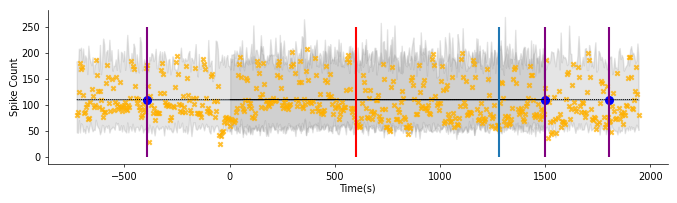

Not enough variance in fitted GP
OFF_14
alpha_init:  1.1102230246251565e-16 output_scale_init:  tensor(0.6931, grad_fn=<SoftplusBackward0>)
initial scale: tensor(0.2990, grad_fn=<SoftplusBackward0>) sqrt tensor(0.5468, grad_fn=<SqrtBackward0>)
predicting at heat times: [-297.686892 1500.       1801.165536]


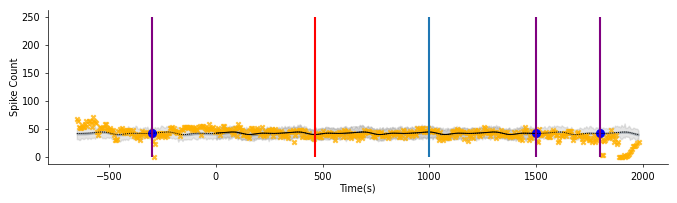

rates:  tensor([0.6203, 0.4842, 0.4758])
OFF_15
alpha_init:  1.1102230246251565e-16 output_scale_init:  tensor(0.6931, grad_fn=<SoftplusBackward0>)
initial scale: tensor(8.1024, grad_fn=<SoftplusBackward0>) sqrt tensor(2.8465, grad_fn=<SqrtBackward0>)
predicting at heat times: [-509.89564  1500.       1802.765752 2144.250828]


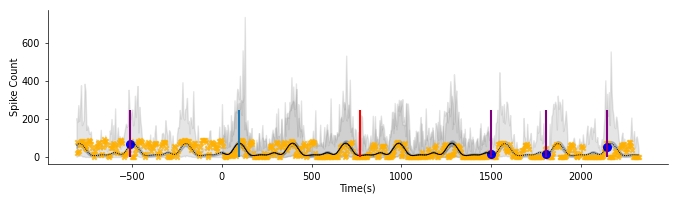

rates:  tensor([0.8899, 0.1182, 0.0904, 0.7234])
OFF_16
alpha_init:  1.1102230246251565e-16 output_scale_init:  tensor(0.6931, grad_fn=<SoftplusBackward0>)
initial scale: tensor(0.9943, grad_fn=<SoftplusBackward0>) sqrt tensor(0.9971, grad_fn=<SqrtBackward0>)
predicting at heat times: [-490.400556 1500.       1901.222032]


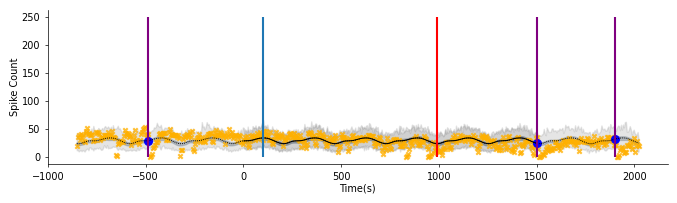

rates:  tensor([0.5523, 0.0732, 0.8332])
OFF_17
alpha_init:  1.1102230246251565e-16 output_scale_init:  tensor(0.6931, grad_fn=<SoftplusBackward0>)
initial scale: tensor(0.2387, grad_fn=<SoftplusBackward0>) sqrt tensor(0.4886, grad_fn=<SqrtBackward0>)
predicting at heat times: [-729.839052 -431.975372 1500.       1831.382772]


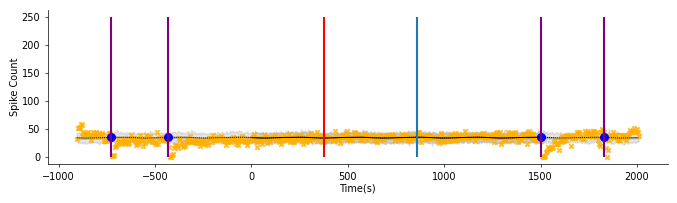

rates:  tensor([0.6809, 0.6339, 0.8786, 0.7115])
OFF_18
alpha_init:  1.1102230246251565e-16 output_scale_init:  tensor(0.6931, grad_fn=<SoftplusBackward0>)
initial scale: tensor(0.6081, grad_fn=<SoftplusBackward0>) sqrt tensor(0.7798, grad_fn=<SqrtBackward0>)
predicting at heat times: [-729.839052 -431.975372 1500.       1831.382772]


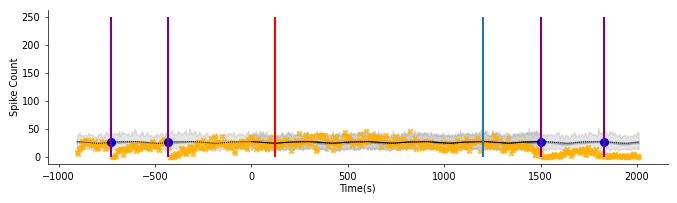

rates:  tensor([0.4742, 0.4218, 0.9675, 0.8492])
OFF_19
alpha_init:  1.1102230246251565e-16 output_scale_init:  tensor(0.6931, grad_fn=<SoftplusBackward0>)
initial scale: tensor(11.1951, grad_fn=<SoftplusBackward0>) sqrt tensor(3.3459, grad_fn=<SqrtBackward0>)
predicting at heat times: [-846.575116 -372.120564 1500.       1787.957824]


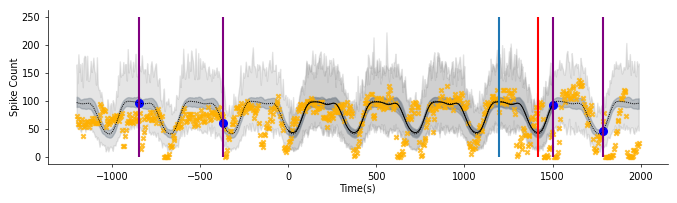

rates:  tensor([0.9530, 0.3244, 0.9084, 0.0655])
OFF_20
alpha_init:  1.1102230246251565e-16 output_scale_init:  tensor(0.6931, grad_fn=<SoftplusBackward0>)
initial scale: tensor(0.4767, grad_fn=<SoftplusBackward0>) sqrt tensor(0.6904, grad_fn=<SqrtBackward0>)
predicting at heat times: [-846.575116 -372.120564 1500.       1787.957824]


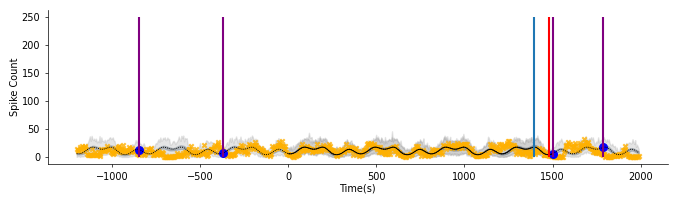

rates:  tensor([0.6709, 0.2042, 0.1296, 0.9710])
OFF_21
alpha_init:  1.1102230246251565e-16 output_scale_init:  tensor(0.6931, grad_fn=<SoftplusBackward0>)
initial scale: tensor(1.0016, grad_fn=<SoftplusBackward0>) sqrt tensor(1.0008, grad_fn=<SqrtBackward0>)
predicting at heat times: [-374.227176 1500.       1819.377752]


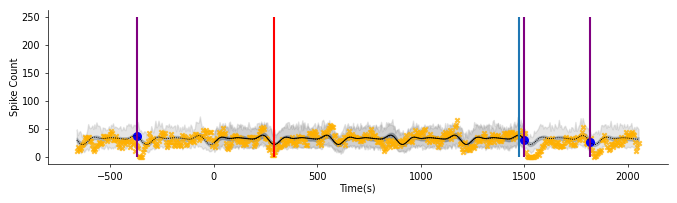

rates:  tensor([0.9308, 0.5171, 0.2520])
OFF_22
alpha_init:  1.1102230246251565e-16 output_scale_init:  tensor(0.6931, grad_fn=<SoftplusBackward0>)
initial scale: tensor(0.1788, grad_fn=<SoftplusBackward0>) sqrt tensor(0.4228, grad_fn=<SqrtBackward0>)
predicting at heat times: [-385.798644 1500.       1819.373092]


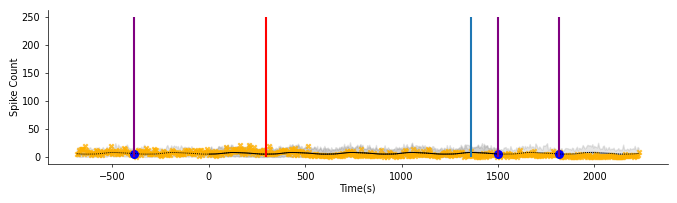

rates:  tensor([0.3118, 0.0669, 0.0304])
OFF_23
alpha_init:  1.1102230246251565e-16 output_scale_init:  tensor(0.6931, grad_fn=<SoftplusBackward0>)
initial scale: tensor(0.2675, grad_fn=<SoftplusBackward0>) sqrt tensor(0.5172, grad_fn=<SqrtBackward0>)
predicting at heat times: [-378.234508 1500.       1767.645328]


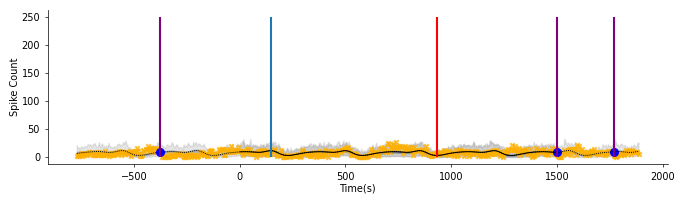

rates:  tensor([0.6725, 0.6573, 0.7922])
OFF_24
alpha_init:  1.1102230246251565e-16 output_scale_init:  tensor(0.6931, grad_fn=<SoftplusBackward0>)
initial scale: tensor(0.1153, grad_fn=<SoftplusBackward0>) sqrt tensor(0.3395, grad_fn=<SqrtBackward0>)
predicting at heat times: [-532.411344 1500.       1800.26934 ]


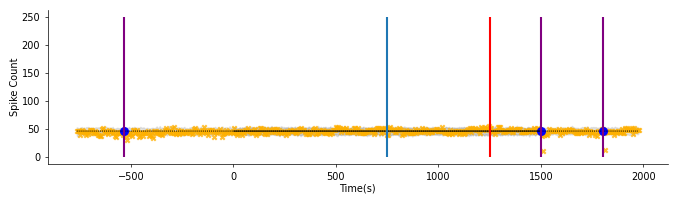

Not enough variance in fitted GP


In [84]:
max_times, periods, withdrawal_rates_dict,latencies = fit_all_cells_using_prior_gp_fit_data(data, base_save_dir, num_iter=200,
                                        num_inducing =100,
                                        save_params=False,save_results=False,from_last=False,
                                        max_count=200,lr=0.05,compare_mean=False,
                                        cell_ids=None,
                                        model_mean=True, 
                                        retrain_mean=False,plot_CI_samples=200)

[array([0.0094835 , 0.82491523, 0.74094075, 0.00910731]), array([0.00603599, 0.85395789, 0.40992348, 0.00204498]), array([-0.01536795,  0.8204668 ,  0.53197485, -0.02246181]), array([0.48600236, 0.67247212, 0.09398784, 0.155988  ]), array([0.6754296]), array([0.58903557]), array([0.17631444, 0.96098842, 0.00772785]), array([1.29503416e-04, 5.86019379e-01, 7.91124501e-04]), array([1.15450577e-05, 8.97591724e-01, 5.58460131e-04]), array([ 0.26542019, -0.03123521,  0.67890776]), array([0.48599218, 0.2811115 , 0.12958998, 0.9963963 ]), array([0.00696185, 0.41555231, 0.24147129]), nan, array([ 0.02105007, -0.01805357,  0.28029479,  0.50039784]), array([1.64743299e-04, 5.18517503e-03, 5.36030425e-01, 3.12995959e-02]), array([0.55549505, 0.07518954, 0.40592822]), array([0.08650112, 0.37282714, 0.47462028]), array([0.06968532, 0.34083214, 0.04585211, 0.694965  ]), array([0.19530271, 0.18256101, 0.23543305, 0.2650661 ]), array([8.68616207e-01, 1.95135668e-05, 1.51094967e-01, 1.96542805e-01,
   

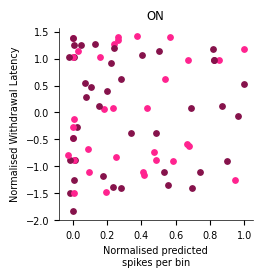

[array([ 0.93773438, -0.00144091,  0.35854258,  0.74571673]), array([0.00229552, 0.00804421, 0.58150367]), array([0.98306487, 0.44582659, 0.90379045]), array([ 0.19764222,  0.71895861, -0.0011613 ]), array([2.55443378e-04, 8.96039952e-01, 7.63405459e-01]), array([0.43528878, 0.12083659, 0.98825821, 0.08634048]), array([0.51226418, 0.3826391 , 0.98886133, 0.14670971]), array([0.38557097, 0.69662486, 0.95368674, 0.01386003]), array([0.40859724, 0.39986668, 0.69348291]), array([0.01598453, 0.47122758, 0.49155831]), array([0.03503441, 0.69047149, 1.00776702]), array([1.01968533, 0.12245604, 0.51714561, 0.09565615]), array([9.60012402e-05, 8.87270632e-01, 1.43955286e-01, 1.16837613e-01,
       2.92658838e-02]), nan, array([0.62034031, 0.48417252, 0.47577562]), array([0.88987628, 0.11824154, 0.09044028, 0.72342204]), array([0.55233079, 0.07316913, 0.83315741]), array([0.68086679, 0.63389438, 0.87855552, 0.71154368]), array([0.47422771, 0.42183491, 0.96753619, 0.84918906]), array([0.95303552,

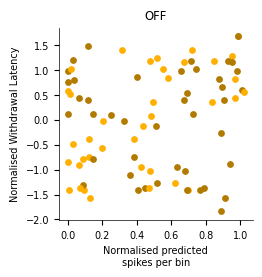

In [85]:
def plot_normalised_withdrawal_latency_against_predicted_spikes(save=False):
    for cell_type in ["ON","OFF"]:
        plt.rcParams.update({'font.size': 7,'xtick.labelsize': 7,'ytick.labelsize': 7})
        fig, ax = plt.subplots(figsize=(2.5,2.5))
        colors = generate_color_spectrum(get_cell_colour(names=cell_type),num_colors = len(latencies),var_size=0.3)
        ax.set_prop_cycle('color', colors)
        ax.spines[["right","top"]].set_visible(False)
        rates_list = []
        for w in withdrawal_rates_dict[cell_type]:
            rates_list.append(w.numpy() if isinstance(w,torch.Tensor) else w)
        print(rates_list)
        for latencies_single_cell, rates in zip(latencies[cell_type],rates_list):
            normalized_latencies_single_cell = (np.array(latencies_single_cell) - np.mean(latencies_single_cell)) / np.std(latencies_single_cell)
            if rates is not np.nan:
                plt.scatter(rates,normalized_latencies_single_cell,s=15)
        plt.ylabel("Normalised Withdrawal Latency")
        plt.xlabel("Normalised predicted\nspikes per bin")
        plt.title(cell_type)
        save_in_folder(f"{cell_type}_pred_spike_vs_withdrawal",svg=True,save=True)

plot_normalised_withdrawal_latency_against_predicted_spikes(save=save_final_plots)

In [86]:
def get_phase(t_i,t,period):
    return np.abs(np.angle(np.exp(1j * (t-t_i) / period )))

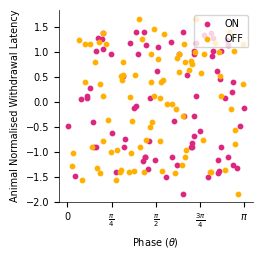

In [87]:
fig, ax = plt.subplots(figsize=(2.5,2.5))

def plot_phase_vs_withdrawal_latency(save=False):

    plt.rcParams.update({'font.size': 7,'xtick.labelsize': 7,'ytick.labelsize': 7})
    for cell_type, times in max_times.items():
        latency_time_phase_pairs = []
        for time, t_start, t_stop, period, cut_cell in zip(times,t_starts[cell_type],t_stops[cell_type],periods[cell_type], cut_spikes_df[cell_type]):
            time = time.numpy()
            period = period.detach().numpy()[0][0]
            origin = cut_cell.file_origin.split("\\")[-1]


            heat_delay_pairs: pd.DataFrame = TF_clean[TF_clean['file_origin'] == origin[:-5]][['TF_latency','heat_time']]
            heat_delay_pairs['TF_latency'] = (heat_delay_pairs['TF_latency'] - np.mean(heat_delay_pairs['TF_latency']))/ np.std(heat_delay_pairs['TF_latency'])


            heat_delay_pairs['phase'] = heat_delay_pairs.apply(lambda x: get_phase(x.heat_time.magnitude,time + t_start.magnitude,period),axis=1)
            
            if np.all(heat_delay_pairs.notna()):
                latency_time_phase_pairs.extend([row for row in heat_delay_pairs.itertuples(index=False)])
            
        latency_time_phase = pd.DataFrame(latency_time_phase_pairs,columns=["latency","time","phase"])


    ax.legend(loc='upper right')
    ax.spines[["right","top"]].set_visible(False)
    ax.set_xlabel("Phase ($\\theta$)")
    ax.set_xticks([0,np.pi/4,np.pi/2,3*np.pi/4, np.pi],["0","$\\frac{\pi}{4}$","$\\frac{\pi}{2}$","$ \\frac{3\pi}{4}$", "$ \pi$"])
    ax.set_ylabel("Animal Normalised Withdrawal Latency")
    save_in_folder("phase_vs_latency",svg=True,save=save)

plot_phase_vs_withdrawal_latency(save=save_final_plots)

Okay, so I can run the GPs on the cut data. What I need to do is now to run the same GPs on the full data. So: 
- Find the full data corresponding to each GP
    - Find the corresponding spiketrain
    - Bin it in the same way as the GP was trained
- Apply the GP to predict the full data, including the times of trial. 

I can find the phase at the time of trial by noting that phase goes from $0$ to $2\pi$. If I can define phase, then I can simply define where $0$ phase is as something consistent (such as the maximum firing rate of the periodic GP) and then extrapolate backwards by using the period length. 

If the period length is $T$, I know that $t_{0}$ is $0$ phase, and I know that the times of withdrawal are $\{t_i\}$ then the phase at each withdrawal time (or potentially each application of heat) is

$ \frac{t_{0} - {t_i}}{T} * 2 \pi,  \mod {2\pi} $

This phase analysis is slightly confounded because the activity of the cells isn't linear, and exhibits multiple (and very flat) peaks at trial time. However, we can still estimate the firing rate that would have occured at that time...